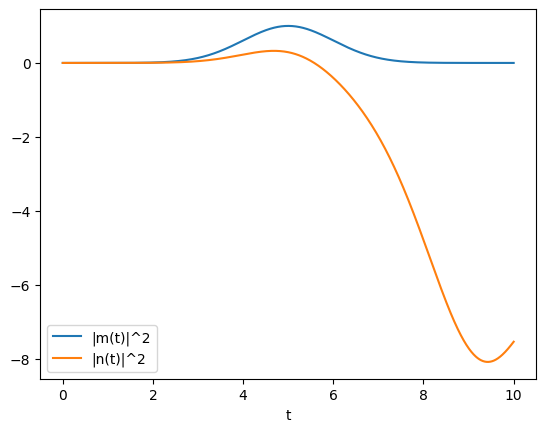

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# パラメータ
c = 1.0
t_start = 0.0
t_end = 10.0
dt = 0.01
t = np.arange(t_start, t_end + dt, dt)

# 既知の関数 |m(t)|^2 の例
m_abs2 = np.exp(-0.5*(t-5)**2)

# 既知の関数 Gamma_f(t) の例
Gamma_f = 1.0 + 0.5 * np.sin(t)

# n_abs2 の初期化（|n(t)|^2）
n_abs2 = np.zeros_like(t)

# 積分項 x_i = \int^{t_i} (|m|^2 - |n|^2) dt を離散化で累積和で計算
x = np.zeros_like(t)

for i in range(1, len(t)):
    # x[i-1] まで計算済みなので、x[i] は
    x[i] = x[i-1] + dt*(m_abs2[i-1] - n_abs2[i-1])
    
    denom = x[i] - 1.0
    if abs(denom) < 1e-8:
        denom = 1e-8  # 0割り防止
    
    # 代数方程式を n_abs2[i] について解く
    # 与えられた式を n_abs2[i] の形に整理する
    # 左辺：(1+c)(m_abs2[i] - n_abs2[i])
    # 右辺：(Gamma_f[i] + c*m_abs2[i]/denom)*x[i] - c*m_abs2[i]/denom

    # n_abs2[i] を左辺にまとめる
    left = (1 + c)
    right = (Gamma_f[i] + c * m_abs2[i] / denom) * x[i] - c * m_abs2[i] / denom

    # n_abs2[i] = m_abs2[i] - right / left
    n_abs2[i] = m_abs2[i] - right / left

# プロット
plt.plot(t, m_abs2, label='|m(t)|^2')
plt.plot(t, n_abs2, label='|n(t)|^2')
plt.xlabel('t')
plt.legend()
plt.show()


In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [2]:
const = 3e-3 * 2 * np.pi

def sech_0(time, const):
    center = (time[0] + time[-1]) / 2
    return (const/2)**0.5/np.cosh(const*(time-center))

def sech_1(time, const):
    center = (time[0] + time[-1]) / 2
    return (6*const**3/(np.pi**2))**0.5/np.cosh(const*(time-center))*(time-center)

def sech_2(time, const):
    center = (time[0] + time[-1]) / 2
    return (45*(2*const)**5/64/(np.pi**4))**0.5/np.cosh(const*(time-center))*((time-center)**2-(np.pi/2/const)**2/3)

def sech_3(time, const):
    center = (time[0] + time[-1]) / 2
    return (175*(2*const)**7)**0.5/24/(np.pi**3)/np.cosh(const*(time-center))*((time-center)**3-(7*(time-center)*(np.pi/(2*const))**2/5))



In [3]:
from mpmath import *
def gamma_t(time, const, plot=0, form="sech",):
    center = (time[0] + time[-1]) / 2
    def Li_2(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(2, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_3(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(3, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_4(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(4, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_5(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(5, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    def Li_6(values):
        vectorized_polylog = np.vectorize(lambda t: polylog(6, -np.exp(-2 * t)))
        return vectorized_polylog(values)
    if form=="sech_0":
        top = (const/2)/(np.cosh(const*(time-center)))**2
        bottom = 1-(1/2)*(np.tanh(const*(time-center))-np.tanh(const*(time[0]-center)))
    elif form=="sech_1":                                                      
        top = (6*const**3/np.pi**2)*(time-center)**2/(np.cosh(const*(time-center)))**2
        def f(t):
            return 6 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) / np.pi**2
        bottom = 1-(f(const*(time-center))-f(const*(time[0]-center)))
    elif form=="sech_2":                                                    
        top = (45*const**5/2/np.pi**4) * ((time-center)**2 - (np.pi/const)**2/12)**2/ (np.cosh(const * (time - center)))**2
        def f(t):
            f_2 = 6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1)
            f_1 = -np.pi**2 * (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t))) /6
            f_0 = np.pi**4*np.tanh(t)/144
            return 45*(f_2 + f_1 + f_0)/2/np.pi**4
        bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
    elif form=="sech_3":
        top = (350*const**7/9/np.pi**6) * ((time-center)**3 - 7*(np.pi/const)**2/20*(time-center))**2/ (np.cosh(const * (time - center)))**2
        def f(t):
            f_3 = 15*t**4*Li_2(t) + 30*t**3*Li_3(t) + 45*t**2*Li_4(t) + 45*t*Li_5(t) + 45/2*Li_6(t) - t**6*(1 - np.tanh(t)) - 6*t**5*np.log(np.exp(-2 * t) + 1)
            f_2 = -7*np.pi**2*(6*t**2*Li_2(t) + 6*t*Li_3(t) + 3*Li_4(t) - t**4*(1 - np.tanh(t)) - 4*t**3*np.log(np.exp(-2 * t) + 1))/10
            f_1 =  (7*np.pi**2/20)**2* (Li_2(t) + t * (-t - 2 * np.log(np.exp(-2 * t) + 1) + t * np.tanh(t)))
            return 350*(f_3 + f_2 + f_1)/9/np.pi**6
        bottom = 1 - (f(const * (time - center)) - f(const * (time[0] - center)))
    if plot:
        plt.figure(figsize=(6,2))
        plt.plot(time, top/bottom/2/np.pi)
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.show()
    return top/bottom#/2/np.pi

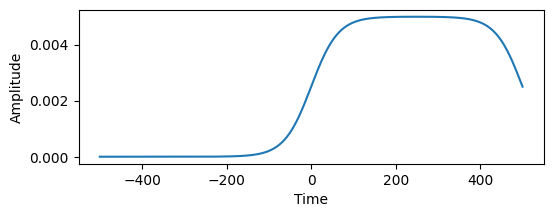

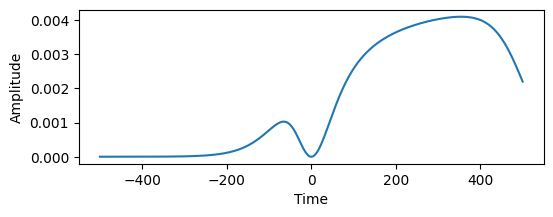

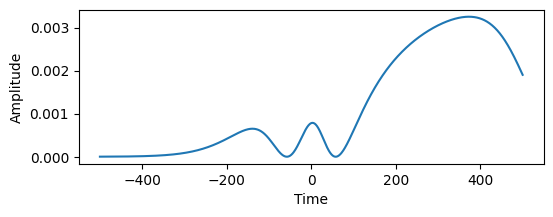

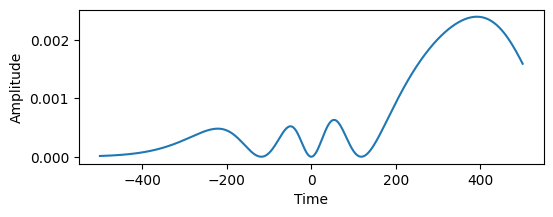

(array([4.73443297e-09, 4.88568420e-09, 5.04176745e-09, 5.20283711e-09,
        5.36905246e-09, 5.54057791e-09, 5.71758309e-09, 5.90024307e-09,
        6.08873849e-09, 6.28325579e-09, 6.48398734e-09, 6.69113167e-09,
        6.90489365e-09, 7.12548470e-09, 7.35312298e-09, 7.58803364e-09,
        7.83044900e-09, 8.08060881e-09, 8.33876049e-09, 8.60515936e-09,
        8.88006888e-09, 9.16376095e-09, 9.45651615e-09, 9.75862401e-09,
        1.00703833e-08, 1.03921024e-08, 1.07240995e-08, 1.10667029e-08,
        1.14202515e-08, 1.17850949e-08, 1.21615939e-08, 1.25501210e-08,
        1.29510604e-08, 1.33648086e-08, 1.37917749e-08, 1.42323814e-08,
        1.46870641e-08, 1.51562725e-08, 1.56404707e-08, 1.61401376e-08,
        1.66557674e-08, 1.71878700e-08, 1.77369717e-08, 1.83036156e-08,
        1.88883621e-08, 1.94917895e-08, 2.01144946e-08, 2.07570932e-08,
        2.14202210e-08, 2.21045338e-08, 2.28107083e-08, 2.35394430e-08,
        2.42914585e-08, 2.50674988e-08, 2.58683312e-08, 2.669474

In [4]:
time = np.linspace(-500, 500, 1000)
const = 2.5e-3 * 2 * np.pi
gamma_t(time, const, plot=1, form="sech_0",), gamma_t(time, const, plot=1, form="sech_1",), gamma_t(time, const, plot=1, form="sech_2",), gamma_t(time, const, plot=1, form="sech_3",)

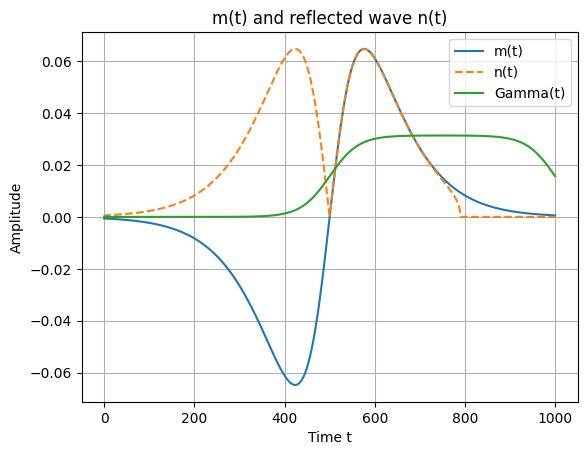

In [5]:
import numpy as np

t = np.linspace(0, 1000, 1000)
dt = t[1] - t[0]

m_t = sech_1(t, const)
Gamma = gamma_t(t, const, plot=0, form="sech_0")

rho = np.zeros_like(t)
n_sq = np.zeros_like(t)

for i in range(1, len(t)):
    rho[i] = rho[i-1] + (m_t[i-1]**2 - n_sq[i-1]) * dt
    n_sq[i] = m_t[i]**2 - Gamma[i] * rho[i]
    if n_sq[i] < 0:
        n_sq[i] = 0.0

n_t = np.sqrt(n_sq)

plt.plot(t, m_t, label='m(t)')
plt.plot(t, n_t, label='n(t)', linestyle='--')
plt.plot(t, Gamma, label='Gamma(t)')

plt.xlabel('Time t')
plt.ylabel('Amplitude')
plt.title('m(t) and reflected wave n(t)')
plt.legend()
plt.grid(True)
plt.show()

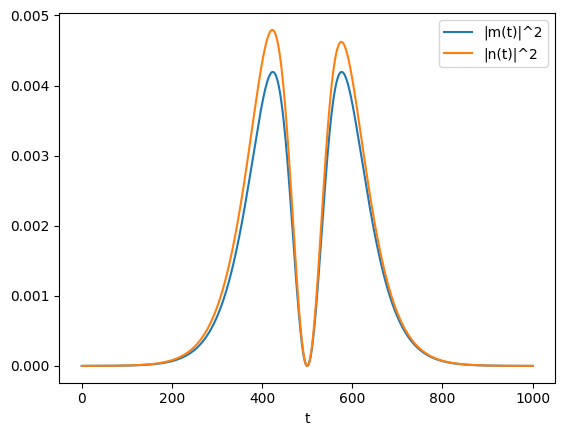

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# パラメータ
c = 5
t_start = 0.0
t_end = 1000
dt = 0.1
t = np.arange(t_start, t_end + dt, dt)

# 既知の関数 |m(t)|^2 の例
m_abs2 = np.abs(sech_1(t, const))**2

# 既知の関数 Gamma_f(t) の例
Gamma_f = gamma_t(t, const, plot=0, form="sech_1")[::-1]

# n_abs2 の初期化（|n(t)|^2）
n_abs2 = np.zeros_like(t)

# 積分項 x_i = \int^{t_i} (|m|^2 - |n|^2) dt を離散化で累積和で計算
x = np.zeros_like(t)

for i in range(1, len(t)):
    # x[i-1] まで計算済みなので、x[i] は
    x[i] = x[i-1] + dt*(m_abs2[i-1] - n_abs2[i-1])
    
    denom = x[i] - 1.0
    if abs(denom) < 1e-8:
        denom = 1e-8  # 0割り防止
    
    # 代数方程式を n_abs2[i] について解く
    # 与えられた式を n_abs2[i] の形に整理する
    # 左辺：(1+c)(m_abs2[i] - n_abs2[i])
    # 右辺：(Gamma_f[i] + c*m_abs2[i]/denom)*x[i] - c*m_abs2[i]/denom

    # n_abs2[i] を左辺にまとめる
    left = (1 + c)
    right = (Gamma_f[i] + c * m_abs2[i] / denom) * x[i] + m_abs2[i] / denom

    # n_abs2[i] = m_abs2[i] - right / left
    n_abs2[i] = m_abs2[i] - right / left

# プロット
plt.plot(t, m_abs2, label='|m(t)|^2')
plt.plot(t, n_abs2, label='|n(t)|^2')
plt.xlabel('t')
plt.legend()
plt.show()


In [7]:
def find_zero_point(envelope):
    diff_envelope = np.diff(envelope)
    sign_change = np.diff(np.sign(diff_envelope))

    inflection_points = np.where(sign_change == 2)[0] 
    
    return inflection_points

def flip_control_envelope( control_envelope, zero_points):
    flipped_envelope = control_envelope.copy()
    
    for i in range(len(zero_points)):  
        if i % 2 == 0:
            start = zero_points[i] + 1
            end = zero_points[i+1] + 1 if i+1 < len(zero_points) else len(control_envelope)
            flipped_envelope[start:end] *= -1  
    
    return flipped_envelope

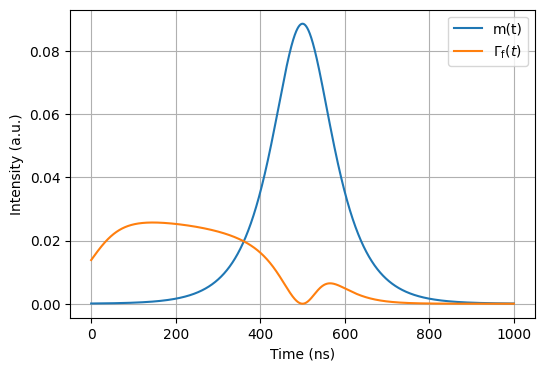

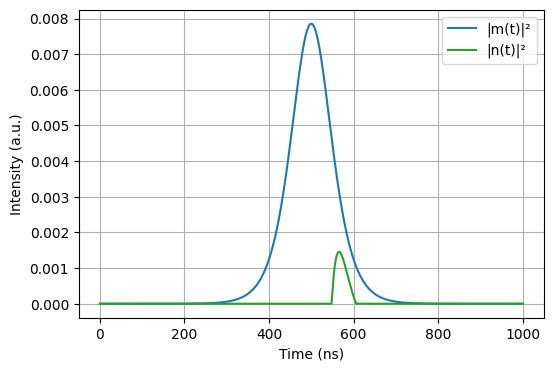

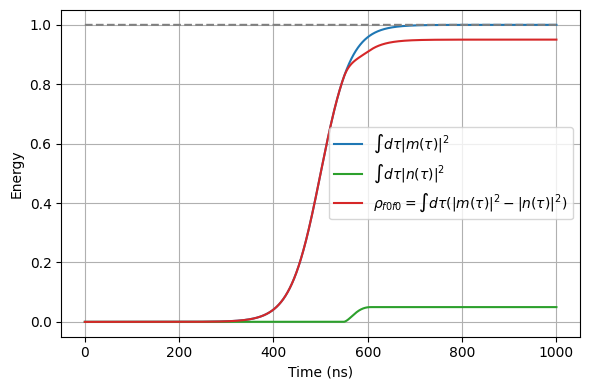

In [22]:
# 0629

import numpy as np
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt

c = 0.01
t_start = 0.0
t_end = 1000
dt = 0.1
t = np.arange(t_start, t_end + dt, dt)
N = len(t)
const = 2.5e-3 * 2 * np.pi


# === compute cumulative integrals ===
m_t = sech_0(t, const) 
m_t_res = sech_1(t, const) 
m_squared = np.abs(m_t)**2
# Gamma_f_t = gamma_t(t, const, plot=0, form="sech_2")[::-1]
m_squared_res = np.abs(m_t_res)**2
Gamma_f_t = np.zeros(N)
int_m = 0.0
for i in range(N):
    Gamma_f_t[i] = m_squared_res [i] / (1 - int_m + 1e-12)  # prevent divide by 0
    if i > 0:
        int_m += 0.5 * (m_squared_res [i] + m_squared_res [i - 1]) * dt
# === Time-reversed Gamma_f_t ===
Gamma_f_t = Gamma_f_t[::-1]
int_m = cumulative_trapezoid(m_squared, t, initial=0.0)


# === set up and solve for n(t) ===
n_t = np.zeros(N, dtype=np.complex128)  # initialize

# === iterative solution ===
int_n = 0.0  # cumulative value of |n(τ)|^2

for i in range(N):
    A = (1 + c)
    B = Gamma_f_t[i] + (2 + c) * np.abs(m_t[i])**2 / (1 - int_m[i] + 1e-10)  # +1e-10 to avoid div by 0
    RHS = -np.abs(m_t[i])**2 + Gamma_f_t[i] * int_m[i]
    
    # Quadratic equation: A * |n|^2 + B * ∫|n|^2 = RHS
    # Let |n|^2 = x
    # => A * x = RHS - B * ∫|n|^2
    x = (RHS - B * int_n) / A
    n_t[i] = np.sqrt(max(x, 0.0))  # ensure positivity
    
    # Update cumulative integral
    if i > 0:
        int_n += 0.5 * (np.abs(n_t[i])**2 + np.abs(n_t[i - 1])**2) * dt

# === plot results ===
plt.figure(figsize=(6, 4))
plt.plot(t, m_t, label='m(t)')
plt.plot(t, Gamma_f_t, label='$\Gamma_\mathrm{f}(t)$')
# plt.plot(t, np.abs(n_t)**2, label='|n(t)|² (rejected)', linestyle='--')
plt.xlabel('Time (ns)')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.grid(True)
# plt.title('Input and Rejected Photon Waveforms')
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(t, np.abs(m_t)**2, label='|m(t)|²')
# plt.plot(t, Gamma_f_t, label='$\Gamma_\mathrm{f}(t)$')
plt.plot(t, np.abs(n_t)**2, color='tab:green', label='|n(t)|²')
plt.xlabel('Time (ns)')
plt.ylabel('Intensity (a.u.)')
plt.legend()
plt.grid(True)
# plt.title('Input and Rejected Photon Waveforms')
plt.show()


integral_m = np.cumsum(np.abs(m_t)**2) * dt  # ∫|m(τ)|^2 dτ
integral_n = np.cumsum(np.abs(n_t)**2) * dt  # ∫|n(τ)|^2 dτ

rho_f0f0 = integral_m - integral_n

energy_total = rho_f0f0 + integral_n + (1.0 - integral_m)  # この和が常に1のはず

plt.figure(figsize=(6, 4))
plt.plot(t, integral_m, label=r'$\int d\tau |m(\tau)|^2$')
plt.plot(t, integral_n, color='tab:green',label=r'$\int d\tau |n(\tau)|^2$')
plt.plot(t, rho_f0f0, color='tab:red',label=r'$\rho_{f0f0} =\int d\tau(|m(\tau)|^2 - |n(\tau)|^2)$')
plt.plot(t, energy_total, '--', color='gray')
plt.xlabel('Time (ns)')
plt.ylabel('Energy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:
# 0629

import numpy as np
from scipy.integrate import cumulative_trapezoid
import matplotlib.pyplot as plt

c = 0.1
t_start = 0.0
t_end = 1000
dt = 0.1
t = np.arange(t_start, t_end + dt, dt)
N = len(t)
const = 2.5e-3 * 2 * np.pi

Gamma_f_t = gamma_t(t, const, plot=0, form="sech_2")[::-1]
# sign_changes = np.where(np.diff(np.sign(Gamma_f_t)) != 0)[0]
# zero_points = find_zero_point(envelope=Gamma_f_t)
# Gamma_f_t = flip_control_envelope(Gamma_f_t, zero_points)

# === compute cumulative integrals ===
m_t = sech_1(t, const) 
int_m = cumulative_trapezoid(np.abs(m_t)**2, t, initial=0.0)

# === set up and solve for n(t) ===
n_t = np.zeros(N, dtype=np.complex128)  # initialize

# === iterative solution ===
int_n = 0.0  # cumulative value of |n(τ)|^2

for i in range(N):
    A = (1 + c)
    B = Gamma_f_t[i] + (2 + c) * np.abs(m_t[i])**2 / (1 - int_m[i] + 1e-10)  # +1e-10 to avoid div by 0
    RHS = -np.abs(m_t[i])**2 + Gamma_f_t[i] * int_m[i]
    
    # Quadratic equation: A * |n|^2 + B * ∫|n|^2 = RHS
    # Let |n|^2 = x
    # => A * x = RHS - B * ∫|n|^2
    x = (RHS - B * int_n) / A
    n_t[i] = np.sqrt(max(x, 0.0))  # ensure positivity
    
    # Update cumulative integral
    if i > 0:
        int_n += 0.5 * (np.abs(n_t[i])**2 + np.abs(n_t[i - 1])**2) * dt

# === plot results ===
plt.figure(figsize=(10, 5))
plt.plot(t, np.abs(m_t)**2, label='|m(t)|² (input)')
plt.plot(t, Gamma_f_t, label='$\Gamma_\mathrm{f}(t)$')
plt.plot(t, np.abs(n_t)**2, label='|n(t)|² (rejected)', linestyle='--')
plt.xlabel('t')
plt.ylabel('Intensity')
plt.legend()
plt.grid(True)
plt.title('Input and Rejected Photon Waveforms')
plt.show()


integral_m = np.cumsum(np.abs(m_t)**2) * dt  # ∫|m(τ)|^2 dτ
integral_n = np.cumsum(np.abs(n_t)**2) * dt  # ∫|n(τ)|^2 dτ

rho_f0f0 = integral_m - integral_n

energy_total = rho_f0f0 + integral_n + (1.0 - integral_m)  # この和が常に1のはず

plt.figure(figsize=(6, 4))
plt.plot(t, integral_m, label=r'$\int d\tau |m(\tau)|^2$')
plt.plot(t, integral_n, label=r'$\int d\tau |n(\tau)|^2$')
plt.plot(t, rho_f0f0, label=r'$\rho_{f0f0} =\int d\tau(|m(\tau)|^2 - |n(\tau)|^2)$')
plt.plot(t, energy_total, '--', label='total energy', color='gray')
plt.xlabel('t')
plt.ylabel('energy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


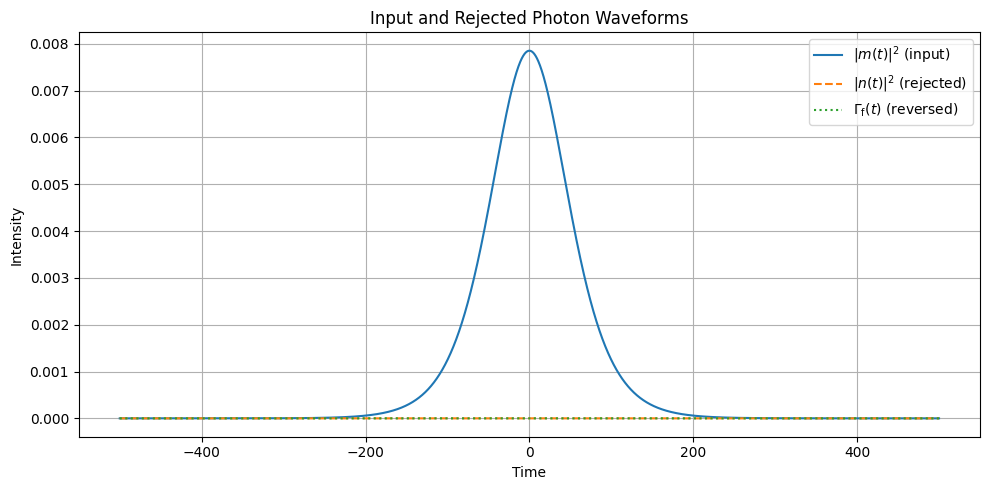

⟨emit|input⟩ = -2.7592945289756088e-17


In [ ]:

# === Parameters ===
c =0.001
t_start = -500
t_end = 500
dt = 0.1
t = np.arange(t_start, t_end + dt, dt)
N = len(t)
const = 2.5e-3 * 2 * np.pi

# === Choose m(t) shape ===
m_t = sech_0(t, const)  # <-- select here
m_t_res = sech_1(t, const)

# === Calculate Gamma_f(t) from emission relation ===
m_squared = np.abs(m_t)**2
m_squared_res = np.abs(m_t_res)**2
Gamma_f_t = np.zeros(N)
int_m = 0.0


for i in range(N):
    Gamma_f_t[i] = m_squared_res [i] / (1 - int_m + 1e-12)  # prevent divide by 0
    if i > 0:
        int_m += 0.5 * (m_squared_res [i] + m_squared_res [i - 1]) * dt

# === Time-reversed Gamma_f_t ===
Gamma_f_t = Gamma_f_t[::-1]

# === Calculate cumulative ∫|m|^2 ===
int_m = cumulative_trapezoid(m_squared, t, initial=0.0)

# === Solve for n(t) iteratively ===
n_t = np.zeros(N, dtype=np.complex128)
int_n = 0.0

for i in range(N):
    A = 1 + c
    B = Gamma_f_t[i] + (2 + c) * m_squared[i] / (1 - int_m[i] + 1e-12)
    RHS = -m_squared[i] + Gamma_f_t[i] * int_m[i]
    x = (RHS - B * int_n) / A
    n_t[i] = np.sqrt(max(x, 0.0))  # non-negative

    if i > 0:
        int_n += 0.5 * (np.abs(n_t[i])**2 + np.abs(n_t[i - 1])**2) * dt

# === Plot results ===
plt.figure(figsize=(10, 5))
plt.plot(t, m_squared, label=r'$|m(t)|^2$ (input)')
plt.plot(t, np.abs(n_t)**2, label=r'$|n(t)|^2$ (rejected)', linestyle='--')
plt.plot(t, Gamma_f_t, label=r'$\Gamma_\mathrm{f}(t)$ (reversed)', linestyle=':')
plt.xlabel('Time')
plt.ylabel('Intensity')
plt.title('Input and Rejected Photon Waveforms')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

overlap = np.trapz(np.conj(m_t_res) * m_t, t)
print("⟨emit|input⟩ =", overlap)

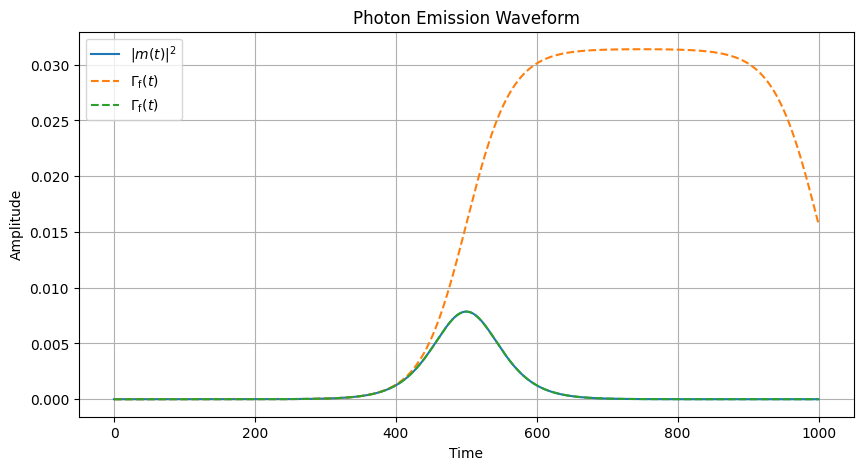

In [68]:
# --- parameters ---
T = 1000
dt = 0.1
t = np.arange(0, T + dt, dt)
N = len(t)
const = 2.5e-3 * 2 * np.pi  # sech parameter
Gamma_f_t = gamma_t(t, const, plot=0, form="sech_0")

m_squared = np.zeros(N)
int_m = 0.0

for i in range(N):
    m_squared[i] = Gamma_f_t[i] * (1 - int_m)
    
    # 更新（台形則による逐次積分）
    if i > 0:
        int_m += 0.5 * (m_squared[i] + m_squared[i - 1]) * dt

# --- plot ---
plt.figure(figsize=(10, 5))
plt.plot(t, m_squared, label=r'$|m(t)|^2$')
plt.plot(t, Gamma_f_t, '--', label=r'$\Gamma_\mathrm{f}(t)$')
plt.plot(t, sech_0(t, const)**2, '--', label=r'$\Gamma_\mathrm{f}(t)$')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Photon Emission Waveform')
plt.grid(True)
plt.legend()
plt.show()

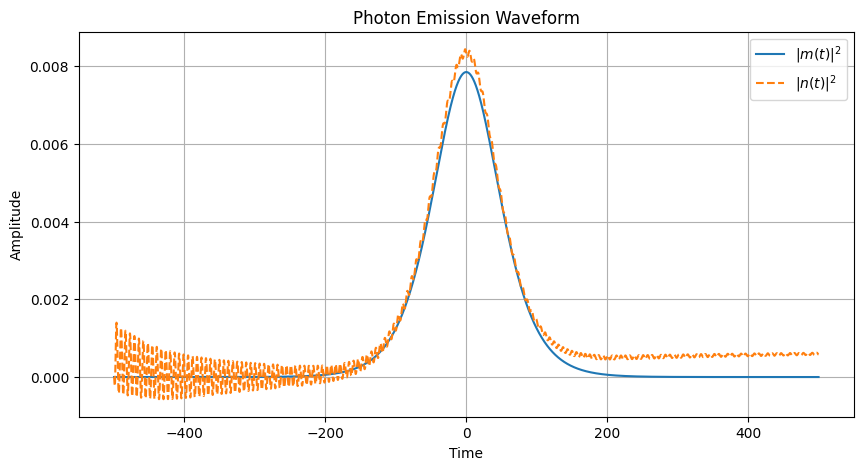

In [103]:
import numpy as np
from scipy.integrate import solve_ivp, cumulative_trapezoid

t_start = -500
t_end = 500
dt = 0.1
num_points = int((t_end - t_start) / dt)+1
t_eval = np.linspace(t_start, t_end, num_points)
const = 2.5e-3 * 2 * np.pi

# === Choose m(t) shape ===
m_t = sech_0(t_eval, const) 
m_res = sech_0(t_eval, const) 

# 累積積分（先に計算）
m_squared = np.abs(m_t)**2
m_squared_res = np.abs(m_t_res)**2
m2_integral = cumulative_trapezoid(m_squared, t_eval, initial=0)
m2_integral = np.clip(m2_integral, 1e-10, None)
int_m = 0.0

for i in range(N):
    Gamma_f_t[i] = m_squared_res [i] / (1 - int_m + 1e-12)  # prevent divide by 0
    if i > 0:
        int_m += 0.5 * (m_squared_res [i] + m_squared_res [i - 1]) * dt

# === Time-reversed Gamma_f_t ===
Gamma_f_t = Gamma_f_t[::-1]

# 定数（任意の代表値）
delta_f0 = 1.0
delta_g1 = 2.0
kappa = 1.0
g_eff = 0.1 + 0.0j
g_ph = 0.2 + 0.0j
Delta_d = 3.0
Gamma_f0g0 = 0.05

def odes(t, y):
    rho_g0f0 = y[0] + 1j * y[1]
    rho_g0g1 = y[2] + 1j * y[3]
    int_m2_minus_n2 = y[4]
    int_n2 = y[5]

    idx = np.searchsorted(t_eval, t)
    if idx >= len(t_eval):
        idx = len(t_eval) - 1  # 安全チェック

    mt = m_t[idx]
    m2 = np.abs(mt)**2
    Gf = Gamma_f_t[idx]

    # rho_g1f0 の近似式（これ自体 complex）
    rho_g1f0 = (Delta_d / kappa - 1j / 2) * Gf * (np.conj(g_eff) * int_m2_minus_n2 + g_ph * rho_g0f0)

    # 微分式
    drho_g0f0 = 1j * (delta_f0 * rho_g0f0 + np.conj(g_eff) * rho_g0g1 - np.conj(g_ph) * rho_g1f0)
    rho_g0g0 = 1 - int_m2_minus_n2
    drho_g0g1 = 1j * (delta_g1 * rho_g0g1 + g_eff * rho_g0f0 + np.conj(g_ph) * rho_g0g0) - (kappa / 2) * rho_g0g1
    d_m2_minus_n2 = (-Gf * int_m2_minus_n2 - Gamma_f0g0 * rho_g0f0).real
    d_int_n2 = (m2 - d_m2_minus_n2).real

    return [
        drho_g0f0.real, drho_g0f0.imag,
        drho_g0g1.real, drho_g0g1.imag,
        d_m2_minus_n2,
        d_int_n2
    ]

# 初期条件
y0 = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

# 解く
sol = solve_ivp(odes, [t_start, t_end], y0, t_eval=t_eval)

# 結果
rho_g0f0 = sol.y[0] + 1j * sol.y[1]
int_m2_minus_n2 = sol.y[4]
n_squared = m_squared - np.gradient(int_m2_minus_n2, t_eval)

plt.figure(figsize=(10, 5))
plt.plot(t_eval, m_squared, label=r'$|m(t)|^2$')
# plt.plot(t, Gamma_f_t, '--', label=r'$\Gamma_\mathrm{f}(t)$')
plt.plot(t_eval, n_squared, '--', label=r'$|n(t)|^2$')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.title('Photon Emission Waveform')
plt.grid(True)
plt.legend()
plt.show()

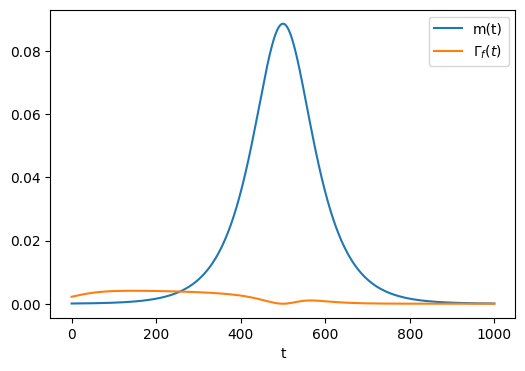

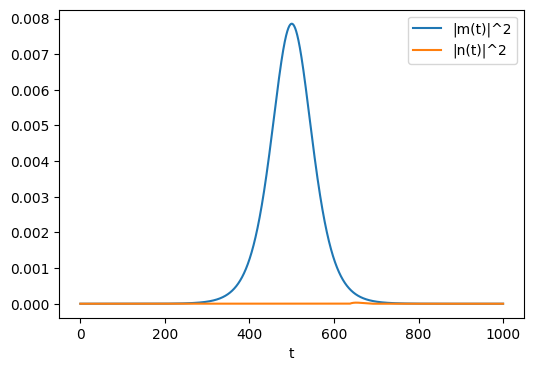

In [7]:
import numpy as np
import matplotlib.pyplot as plt


t_max = 1000
dt = 0.1
t = np.arange(0, t_max, dt)
N = len(t)

c = 0.01

def m(t): 
    return sech_0(t, const)

def Gamma_f(t):
    return gamma_t(t, const, plot=0, form="sech_1")[::-1]
plt.figure(figsize=(6, 4))
plt.plot(t, m(t), label='m(t)')
plt.plot(t, Gamma_f(t), label=r'$\Gamma_f(t)$')
plt.xlabel('t')
plt.legend()
plt.show()

m_vals = m(t)
abs_m2 = np.abs(m_vals)**2
Gamma_f_vals = Gamma_f(t)

integral_m = np.cumsum(abs_m2) * dt  # ∫|m(τ)|^2 dτ
integral_m_minus_n = np.zeros(N)     # ∫(|m|^2 - |n|^2) dτ
abs_n2 = np.zeros(N)                 # |n(t)|^2

eps = 1e-10 
for i in range(N):
    if 1.0 - integral_m[i] < eps:
        Gamma_ph_prime = 1e10
    else:
        Gamma_ph_prime = ((2 + c) * abs_m2[i]) / (c * (1.0 - integral_m[i]))
    
    coeff = Gamma_f_vals[i] + c * Gamma_ph_prime
    rhs = c * Gamma_ph_prime - coeff * integral_m_minus_n[i]
    diff = rhs / (1 + c)
    abs_n2[i] = abs_m2[i] - diff
    abs_n2[i] = max(abs_n2[i], 0.0)

    if i + 1 < N:
        integral_m_minus_n[i + 1] = integral_m_minus_n[i] + (abs_m2[i] - abs_n2[i]) * dt

plt.figure(figsize=(6, 4))
plt.plot(t, abs_m2, label='|m(t)|^2')
plt.plot(t, abs_n2, label='|n(t)|^2')
plt.xlabel('t')
plt.legend()
plt.show()

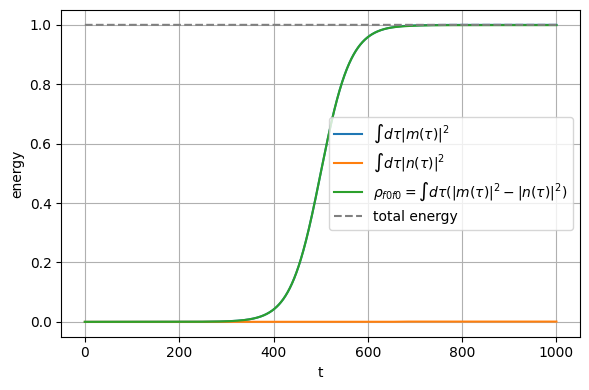

In [8]:

integral_m = np.cumsum(abs_m2) * dt  # ∫|m(τ)|^2 dτ
integral_n = np.cumsum(abs_n2) * dt  # ∫|n(τ)|^2 dτ

rho_f0f0 = integral_m - integral_n

energy_total = rho_f0f0 + integral_n + (1.0 - integral_m)  # この和が常に1のはず

plt.figure(figsize=(6, 4))
plt.plot(t, integral_m, label=r'$\int d\tau |m(\tau)|^2$')
plt.plot(t, integral_n, label=r'$\int d\tau |n(\tau)|^2$')
plt.plot(t, rho_f0f0, label=r'$\rho_{f0f0} =\int d\tau(|m(\tau)|^2 - |n(\tau)|^2)$')
plt.plot(t, energy_total, '--', label='total energy', color='gray')
plt.xlabel('t')
plt.ylabel('energy')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [10]:
overlap = np.trapz(np.conj(sech_0(t, const)) * sech_1(t, const), dx=dt)
print(f"Overlap = {overlap}")

Overlap = -4.106178564321997e-09
